# `preion.theory` tutorial

Reionisation observables from the electron power spectrum, computed with a
single consistent physical model (`Pee_model`): the kSZ angular power
spectrum, the optical depth (tau-tau) power spectrum, the 21cm power
spectrum, and the reionisation B-modes.

Adapted from `With_Pee/compare_models.ipynb` (cells up to its
`## Detectability` section) against the packaged `preion` API.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import cosmology

from preion.theory import Pee_model

%matplotlib inline

could not load wigners.so fortran shared object
try f2py -c -m wigners wigners.f90 from the command line in wigners directory ?


## Building a model

`Pee_model` takes the reionisation-history parameters (`zre_h`, `dz_h`,
`alpha0`, `kappa`) plus a cosmology, and (if `run_camb=True`) runs CAMB once
so all the observables below share the same primary CMB spectra and matter
power spectrum.

In [2]:
cos = cosmology.Planck18

preion_model = Pee_model(
    zre_h=7.0, dz_h=1.5, alpha0=3.7, kappa=0.10,
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    verbose=True, run_camb=True,
)
print(f'tau = {preion_model.tau:.4f}')

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16
tau = 0.0534
Running CAMB...


tau = 0.0534


### Reionisation history

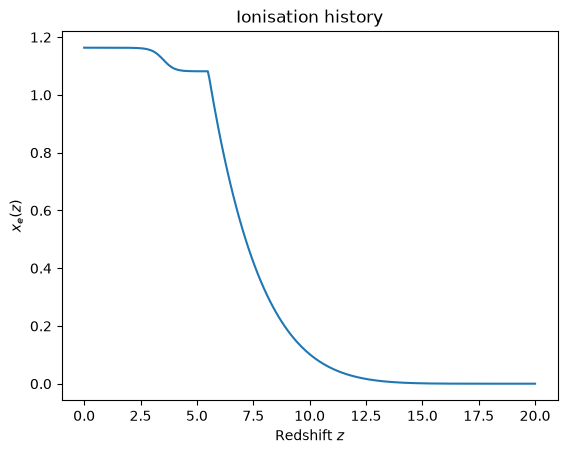

In [3]:
z = np.linspace(0, 20, 300)
xe = preion_model.xe(z)

plt.figure()
plt.plot(z, xe)
plt.xlabel('Redshift $z$')
plt.ylabel('$x_e(z)$')
plt.title('Ionisation history')
plt.show()

### Primary CMB power spectra

 Computing CMB power spectra...


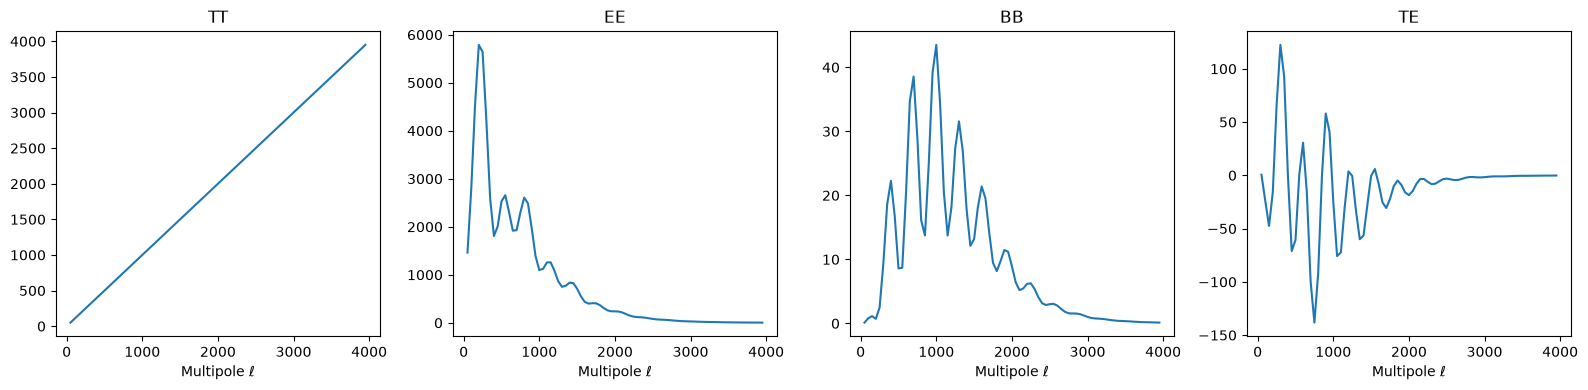

In [4]:
ells = np.arange(50, 4000, step=50)
CMB_Dells = preion_model.get_primary_spectra(ells=ells, Dells=True)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, i, title in zip(axes, range(4), ['TT', 'EE', 'BB', 'TE']):
    ax.plot(ells, CMB_Dells[:, i])
    ax.set_title(title)
    ax.set_xlabel(r'Multipole $\ell$')
fig.tight_layout()
plt.show()

### kSZ power spectrum

`get_ksz` returns $\mathcal{D}_\ell = \ell(\ell+1)C_\ell/2\pi$ for the patchy
and/or late-time (homogeneous) kSZ contributions.

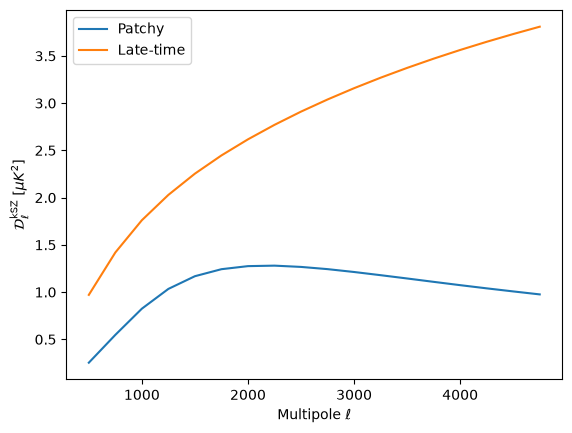

In [5]:
ells_ksz = np.arange(500, 5000, step=250)
ksz_ps = preion_model.get_ksz(ells=ells_ksz, signal='both', Dells=True)

plt.figure()
plt.plot(ells_ksz, ksz_ps[:, 0], label='Patchy')
plt.plot(ells_ksz, ksz_ps[:, 1], label='Late-time')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^\mathrm{kSZ}$ [$\mu K^2$]')
plt.legend()
plt.show()

### Tau-tau power spectrum

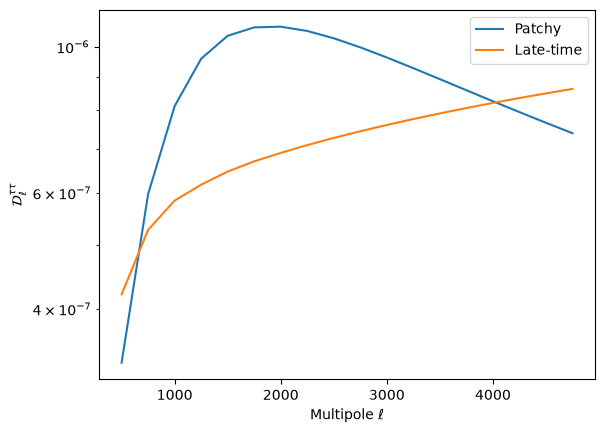

In [6]:
tau_ps = preion_model.get_tau(ells=ells_ksz, signal='both', Dells=True)

plt.figure()
plt.plot(ells_ksz, tau_ps[:, 0], label='Patchy')
plt.plot(ells_ksz, tau_ps[:, 1], label='Late-time')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{\tau\tau}$')
plt.legend()
plt.show()

### 21cm power spectrum

`get_p21(k, z)` gives the 21cm power spectrum at a fixed redshift; here we
show it at a handful of redshifts spanning reionisation.

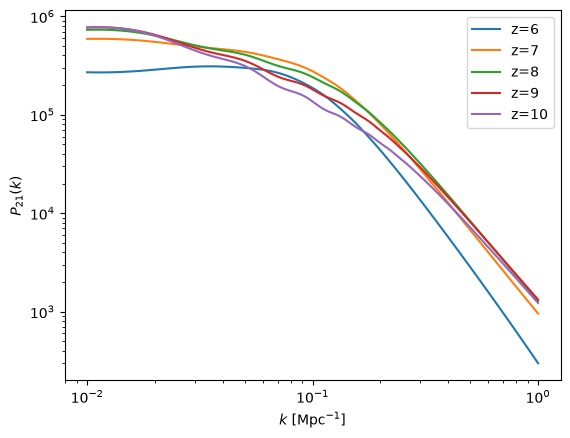

In [7]:
klog = np.logspace(-2, 0, 100)

plt.figure()
for zval in [6., 7., 8., 9., 10.]:
    p21 = preion_model.get_p21(klog, zval)
    plt.plot(klog, p21, label=f'z={zval:.0f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{21}(k)$')
plt.legend()
plt.show()

### $B$-modes

Reionisation sources two types of $B$-modes: scattering (patchy + late-time
Thomson scattering off free electrons) and screening (attenuation of the
primary $E$-modes by patchy $\tau$). `get_B_modes` returns their sum.

 Computing CMB power spectra...


 Computing CMB power spectra...


 Computing CMB power spectra...


 Computing CMB power spectra...


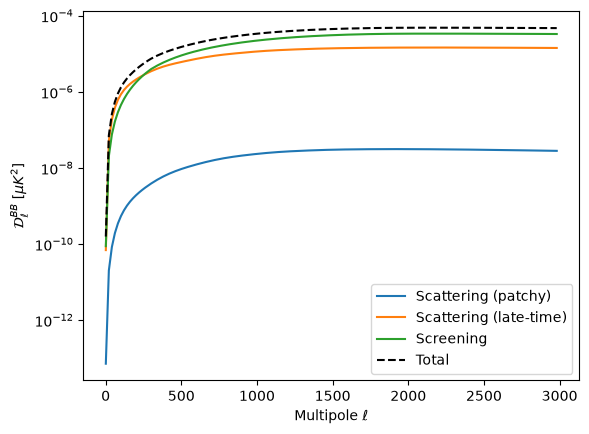

In [8]:
low_ells = np.arange(1, 3000, step=20)

scattering_bb = preion_model.get_scattering_B_modes(ells=low_ells, signal='both', Dells=True)
screening_bb = preion_model.get_screening_B_modes(ells=low_ells, Dells=True)
total_bb = preion_model.get_B_modes(ells=low_ells, Dells=True)

plt.figure()
plt.plot(low_ells, scattering_bb[:, 0], label='Scattering (patchy)')
plt.plot(low_ells, scattering_bb[:, 1], label='Scattering (late-time)')
plt.plot(low_ells, screening_bb, label='Screening')
plt.plot(low_ells, total_bb, 'k--', label='Total')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\mathcal{D}_\ell^{BB}$ [$\mu K^2$]')
plt.legend()
plt.show()

### All observables

A combined view of the four EoR observables computed above, all from the
same underlying `Pee_model` instance.

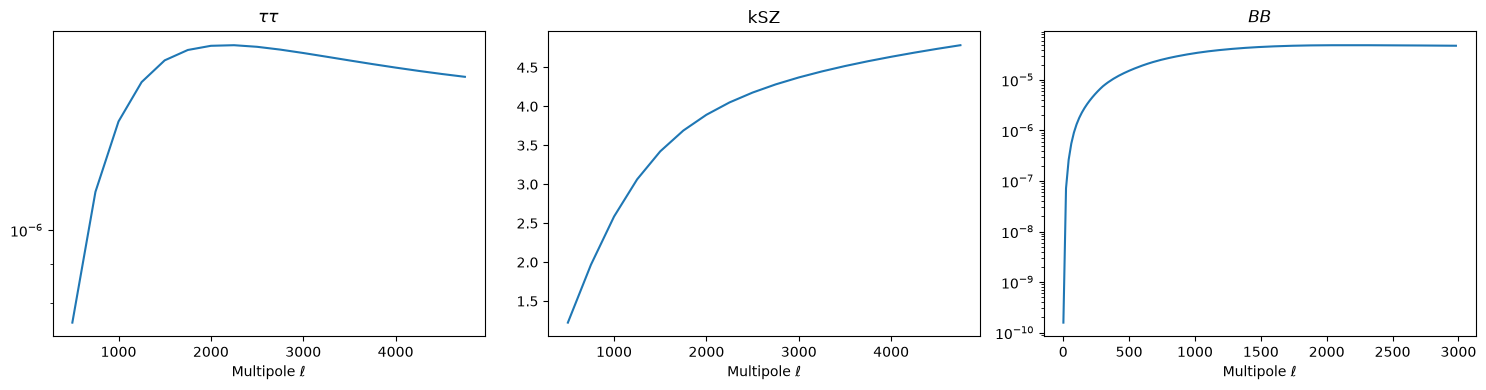

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ells_ksz, tau_ps.sum(axis=1))
axes[0].set_yscale('log')
axes[0].set_title(r'$\tau\tau$')

axes[1].plot(ells_ksz, ksz_ps.sum(axis=1))
axes[1].set_title('kSZ')

axes[2].plot(low_ells, total_bb)
axes[2].set_yscale('log')
axes[2].set_title('$BB$')

for ax in axes:
    ax.set_xlabel(r'Multipole $\ell$')
fig.tight_layout()
plt.show()